### 1. Libraries   


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [23]:
import warnings
warnings.filterwarnings('ignore')

import missingno as mn
from sklearn.impute import SimpleImputer
import itertools
from imblearn.over_sampling import SMOTE


In [24]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score

import warnings
warnings.filterwarnings('ignore')

### 2. Data import

In [69]:
diabetic_data = pd.read_csv('diabetic_data.csv')
diabetic_data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


### 3. Data cleaning
#### Identifying Missingness

In [70]:
diabetic_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

<Axes: >

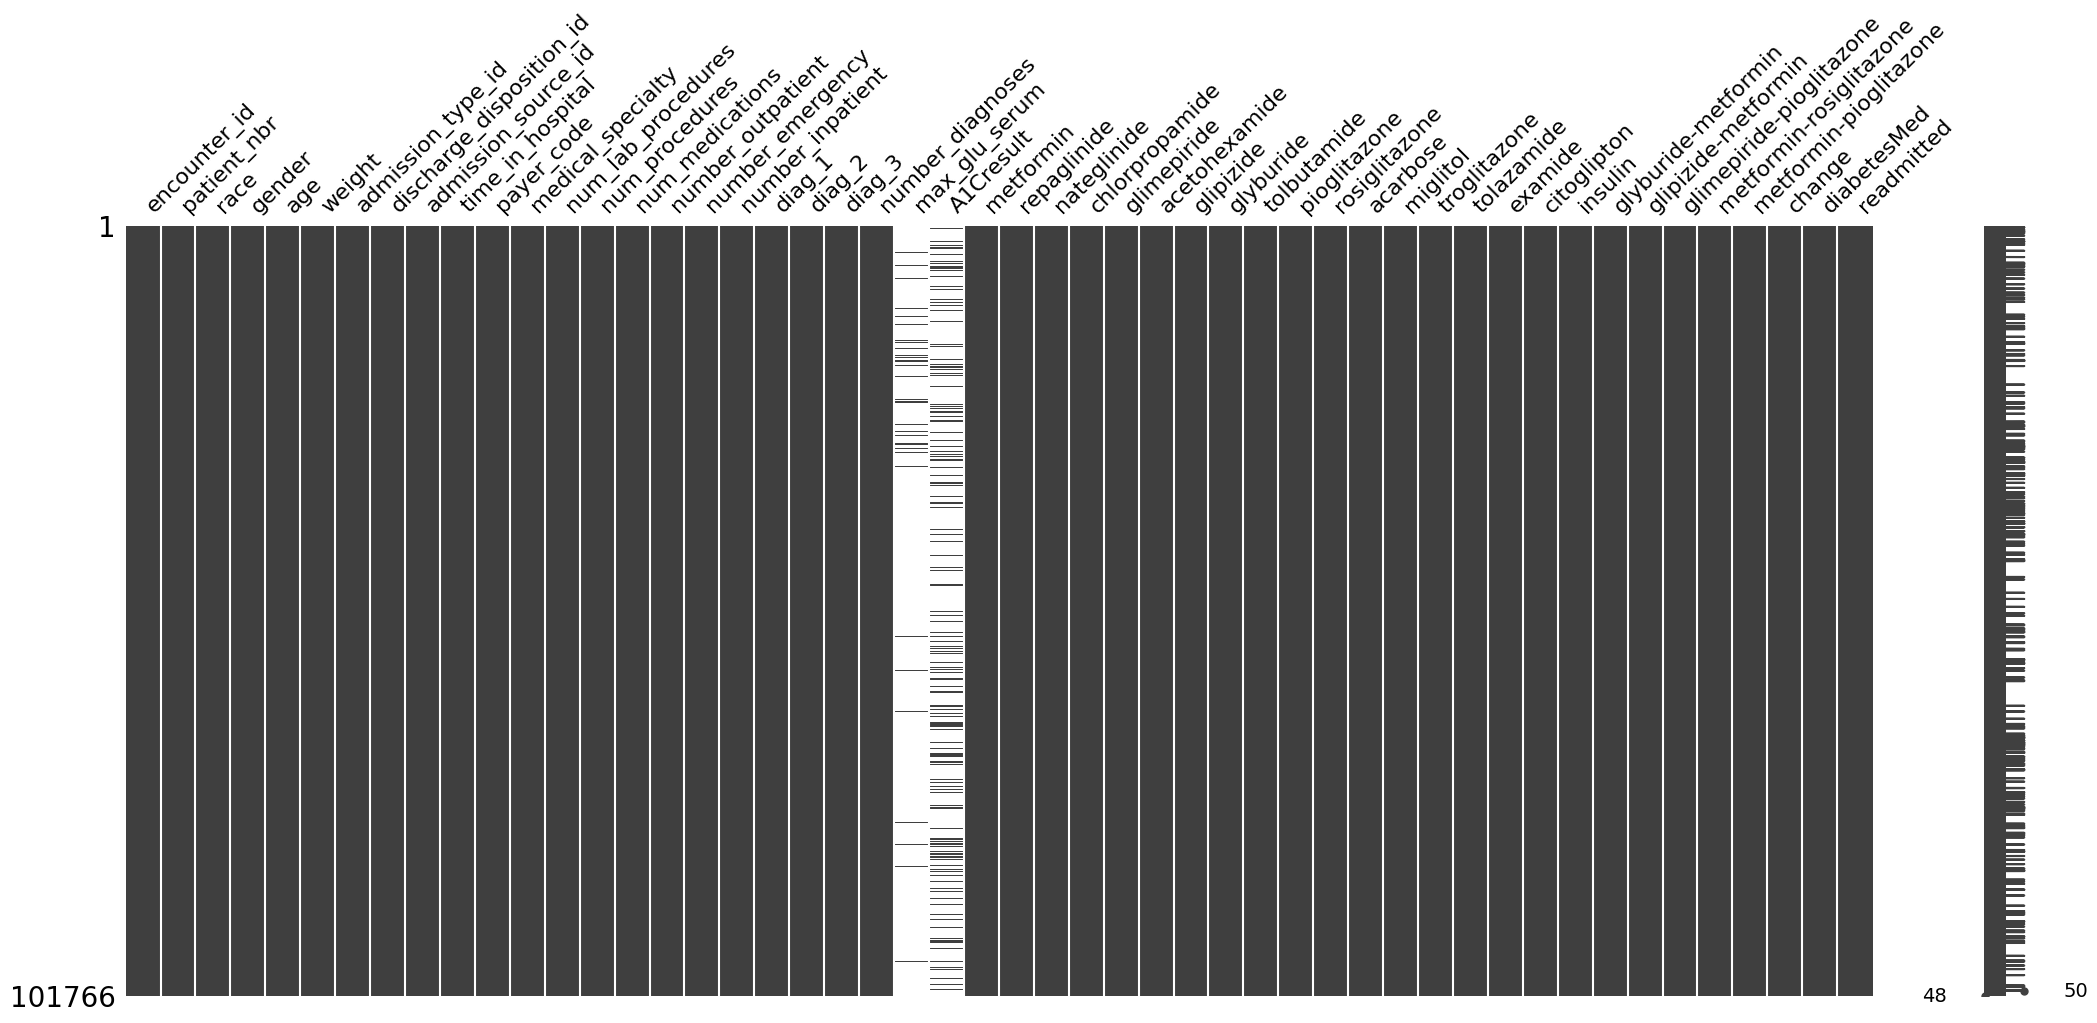

In [71]:
mn.matrix(diabetic_data)


In [72]:
total_missing = diabetic_data.isnull().sum().sort_values(ascending=False)
percent = diabetic_data.isnull().sum().sort_values(ascending=False)/diabetic_data.isnull().count().sort_values(ascending=False)


missing_df = pd.concat([total_missing, percent], axis=1, keys=['Total Missing', 'Percent Missing'], sort=False)
missing_df.index.name = 'variable'# set the index name to variable
missing_df= missing_df[total_missing > 0]# filter the missing_df to only include rows where total_missing is greater than 0
missing_df['percentage_missing'] = missing_df['Percent Missing'].apply(lambda x: f'{x*100:.2f}%')# format the percentage missing as a percentage
missing_df


,Total Missing,Percent Missing,percentage_missing
variable,,,
max_glu_serum,96420,0.947468,94.75%
A1Cresult,84748,0.832773,83.28%


In [73]:
# drop any columns with more than 30% missing values

diabetic_data['glu_tested'] = diabetic_data['max_glu_serum'].notna().astype(int)
diabetic_data['a1c_tested'] = diabetic_data['A1Cresult'].notna().astype(int)
diabetic_data.drop(columns=['max_glu_serum', 'A1Cresult'], inplace=True)


In [74]:
# dropping irrelevant columns
diabetic_data.drop(columns=['encounter_id'], inplace=True)


<Axes: >

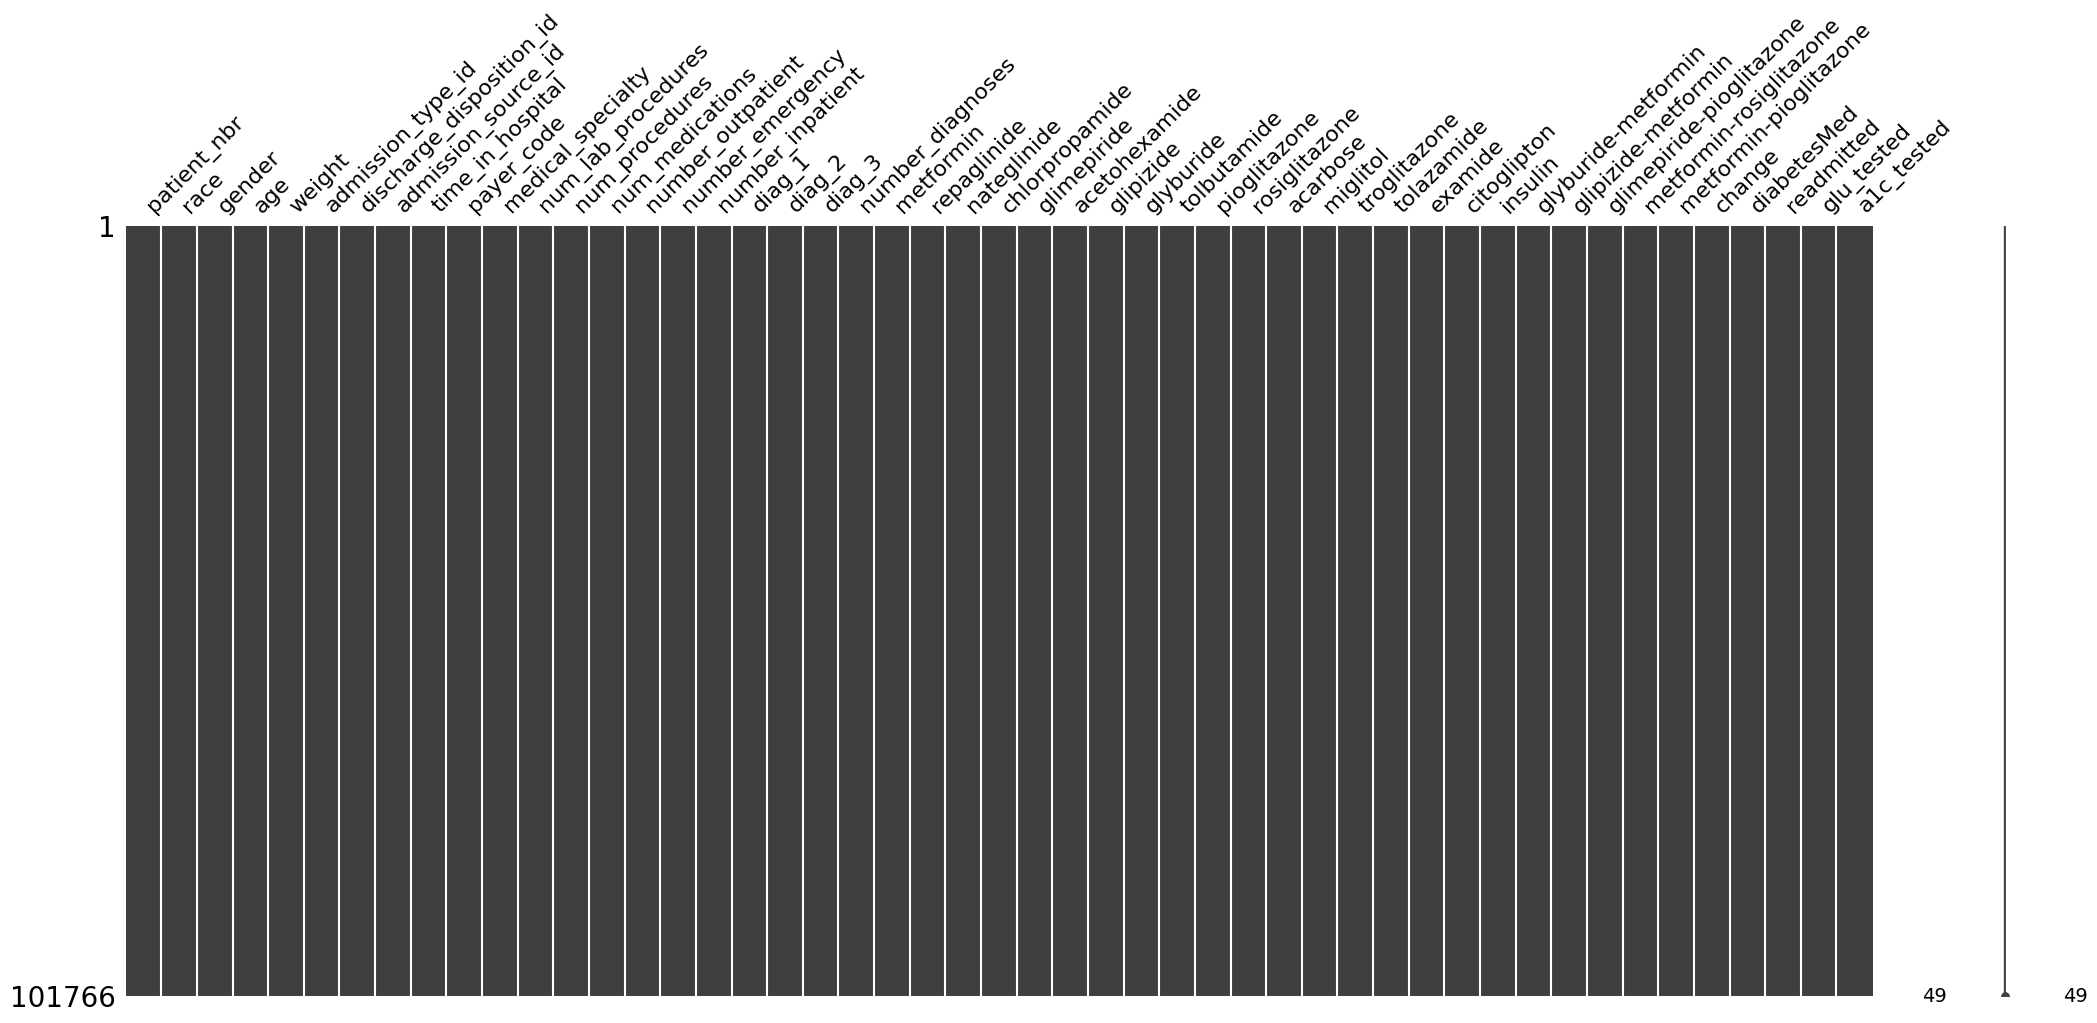

In [ ]:
# confirm that the columns were dropped
mn.matrix(diabetic_data)

In [77]:
diabetic_data.head(10)


,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,glu_tested,a1c_tested
0,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,...,No,No,No,No,No,No,No,NO,0,0
1,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,...,No,No,No,No,No,Ch,Yes,>30,0,0
2,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,...,No,No,No,No,No,No,Yes,NO,0,0
3,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,...,No,No,No,No,No,Ch,Yes,NO,0,0
4,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,...,No,No,No,No,No,Ch,Yes,NO,0,0
5,82637451,Caucasian,Male,[50-60),?,2,1,2,3,?,...,No,No,No,No,No,No,Yes,>30,0,0
6,84259809,Caucasian,Male,[60-70),?,3,1,2,4,?,...,No,No,No,No,No,Ch,Yes,NO,0,0
7,114882984,Caucasian,Male,[70-80),?,1,1,7,5,?,...,No,No,No,No,No,No,Yes,>30,0,0
8,48330783,Caucasian,Female,[80-90),?,2,1,4,13,?,...,No,No,No,No,No,Ch,Yes,NO,0,0
9,63555939,Caucasian,Female,[90-100),?,3,3,4,12,?,...,No,No,No,No,No,Ch,Yes,NO,0,0


In [78]:
# columns that are not appearing as missing
diabetic_data.replace('?', np.nan, inplace=True)

,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,glu_tested,a1c_tested
0,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,...,No,No,No,No,No,No,No,NO,0,0
1,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,...,No,No,No,No,No,Ch,Yes,>30,0,0
2,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,...,No,No,No,No,No,No,Yes,NO,0,0
3,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,...,No,No,No,No,No,Ch,Yes,NO,0,0
4,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,...,No,No,No,No,No,Ch,Yes,NO,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,MC,...,No,No,No,No,No,Ch,Yes,>30,0,1
101762,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,MC,...,No,No,No,No,No,No,Yes,NO,0,0
101763,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,MC,...,No,No,No,No,No,Ch,Yes,NO,0,0
101764,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,MC,...,No,No,No,No,No,Ch,Yes,NO,0,0


<Axes: >

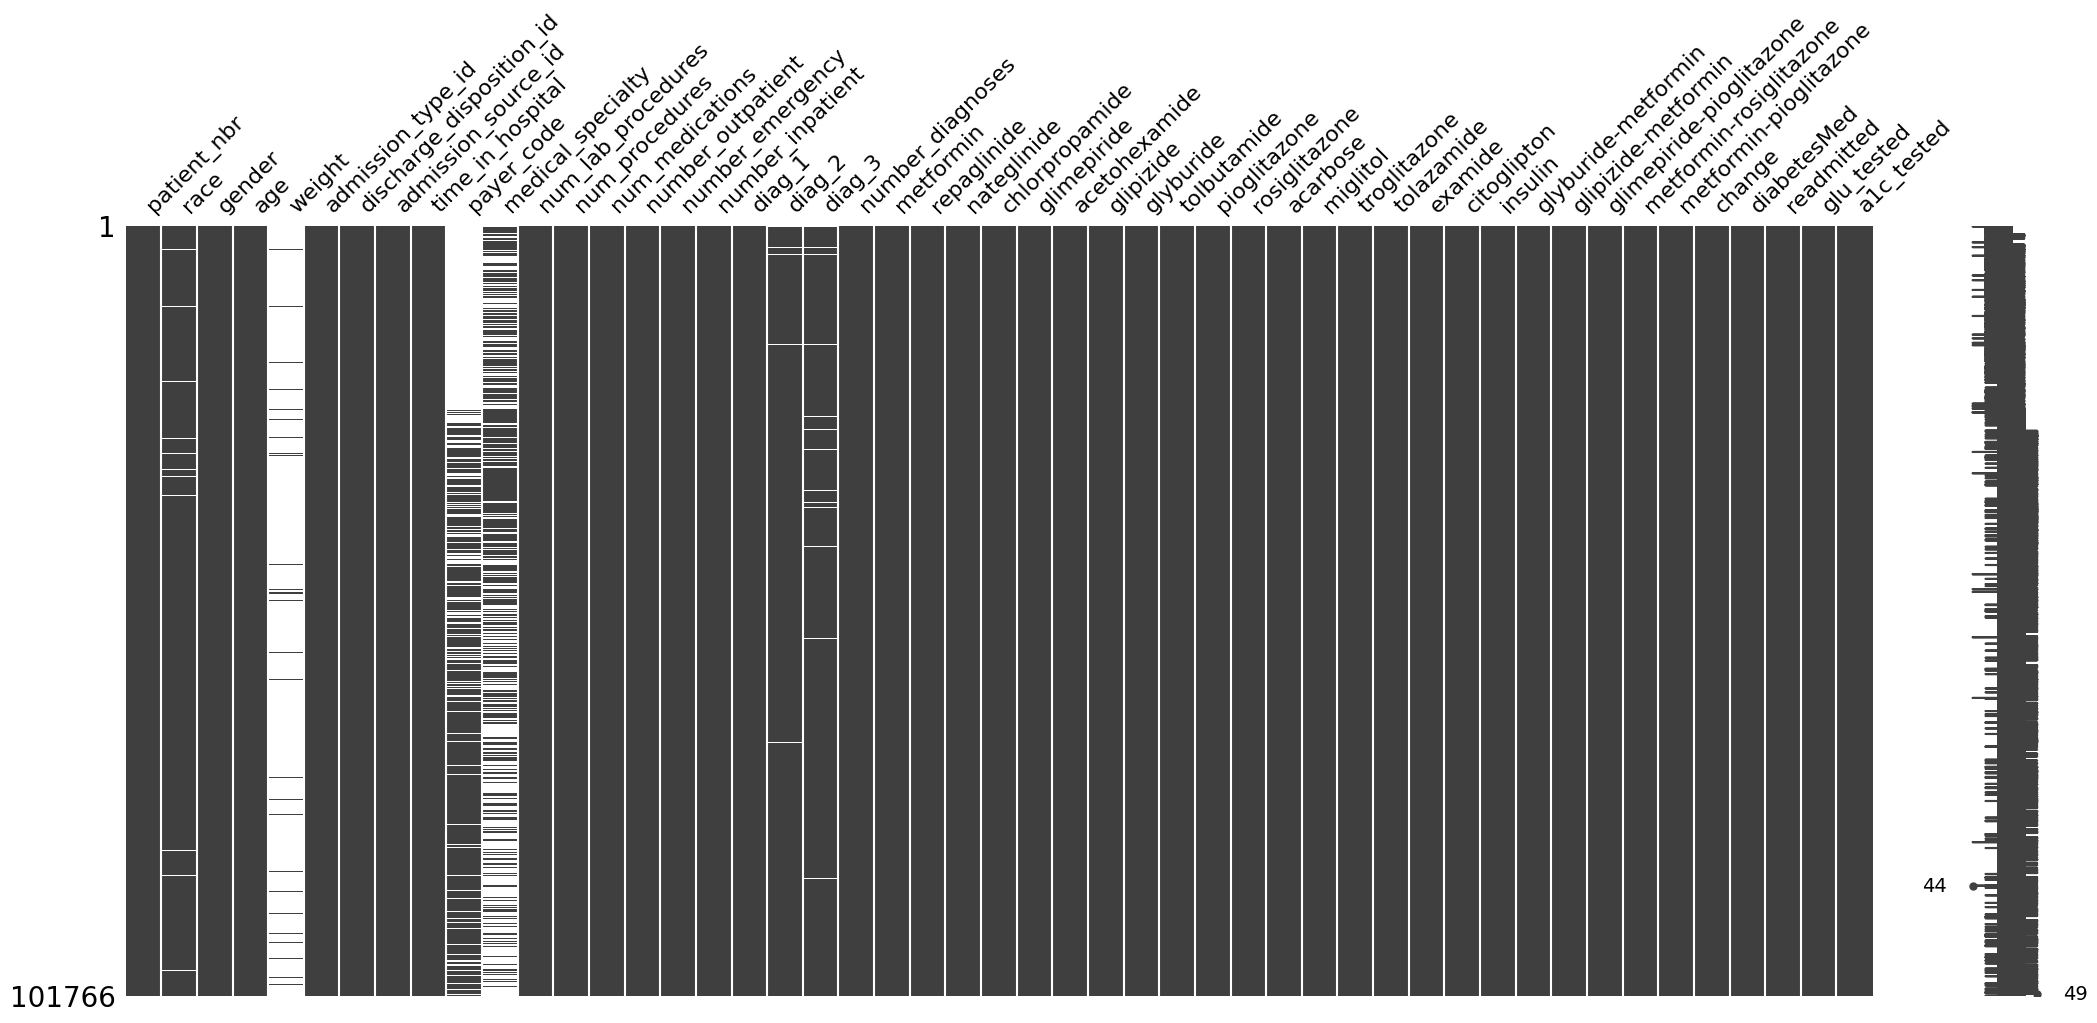

In [79]:
mn.matrix(diabetic_data)

In [80]:
new_total_missing = diabetic_data.isnull().sum().sort_values(ascending=False)
percent = diabetic_data.isnull().sum().sort_values(ascending=False)/diabetic_data.isnull().count().sort_values(ascending=False)


missing_df = pd.concat([new_total_missing, percent], axis=1, keys=['Total Missing', 'Percent Missing'], sort=False)
missing_df.index.name = 'variable'# set the index name to variable
missing_df= missing_df[new_total_missing > 0]# filter the missing_df to only include rows where new_total_missing is greater than 0
missing_df['percentage_missing'] = missing_df['Percent Missing'].apply(lambda x: f'{x*100:.2f}%')# format the percentage missing as a percentage
missing_df

,Total Missing,Percent Missing,percentage_missing
variable,,,
weight,98569,0.968585,96.86%
medical_specialty,49949,0.490822,49.08%
payer_code,40256,0.395574,39.56%
race,2273,0.022336,2.23%
diag_3,1423,0.013983,1.40%
diag_2,358,0.003518,0.35%
diag_1,21,0.000206,0.02%


In [81]:
# Dropping any columns with more than 40% missing values

diabetic_data.drop(columns=['weight','payer_code', 'medical_specialty'], inplace=True)

#### Imputation for missingness

In [82]:
# Imputing for missingness below 30%
# 1. Race

cat_cols_1 = ['race'] 

imputer = SimpleImputer(strategy='most_frequent') 
diabetic_data_imputed = diabetic_data.copy()
diabetic_data_imputed[cat_cols_1] = imputer.fit_transform(diabetic_data[cat_cols_1])

# do EDA to confirm that the imputation strategy is appropriate for the data?


In [83]:
# 2. Diagnostic Codes
cat_cols_2 = ['diag_1', 'diag_2', 'diag_3']

imputer = SimpleImputer(strategy='most_frequent')
diabetic_data_imputed[cat_cols_2] = imputer.fit_transform(diabetic_data[cat_cols_2])


In [84]:
total_missing = diabetic_data_imputed.isnull().sum().sort_values(ascending=False)
percent = diabetic_data_imputed.isnull().sum().sort_values(ascending=False)/diabetic_data_imputed.isnull().count().sort_values(ascending=False)


missing_df = pd.concat([total_missing, percent], axis=1, keys=['Total Missing', 'Percent Missing'], sort=False)
missing_df.index.name = 'variable'# set the index name to variable
missing_df= missing_df[total_missing > 0]# filter the missing_df to only include rows where total_missing is greater than 0
missing_df['percentage_missing'] = missing_df['Percent Missing'].apply(lambda x: f'{x*100:.2f}%')# format the percentage missing as a percentage
missing_df

,Total Missing,Percent Missing,percentage_missing
variable,,,


### 4. EDA

##### Target variable

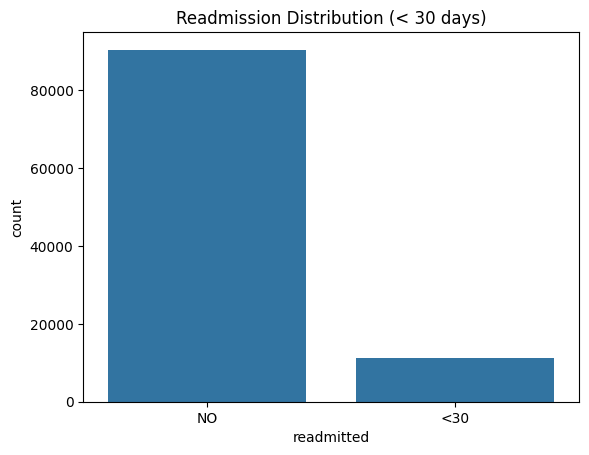

readmitted
NO     0.888
<30    0.112
Name: proportion, dtype: float64


In [86]:
# Binary classification
# Redefine readmitted: <30 days = YES (clinically significant), everything else = NO

diabetic_data_imputed['readmitted'] = diabetic_data_imputed['readmitted'].replace('>30', 'NO')

sns.countplot(data=diabetic_data_imputed, x='readmitted', order=['NO', '<30'])

plt.title('Readmission Distribution (< 30 days)')
plt.show()

# Proportions
print(diabetic_data_imputed['readmitted'].value_counts(normalize=True).round(3))

##### Numeric features

In [87]:
diabetic_data_imputed.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 46 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   patient_nbr               101766 non-null  int64
 1   race                      101766 non-null  str  
 2   gender                    101766 non-null  str  
 3   age                       101766 non-null  str  
 4   admission_type_id         101766 non-null  int64
 5   discharge_disposition_id  101766 non-null  int64
 6   admission_source_id       101766 non-null  int64
 7   time_in_hospital          101766 non-null  int64
 8   num_lab_procedures        101766 non-null  int64
 9   num_procedures            101766 non-null  int64
 10  num_medications           101766 non-null  int64
 11  number_outpatient         101766 non-null  int64
 12  number_emergency          101766 non-null  int64
 13  number_inpatient          101766 non-null  int64
 14  diag_1                    10176

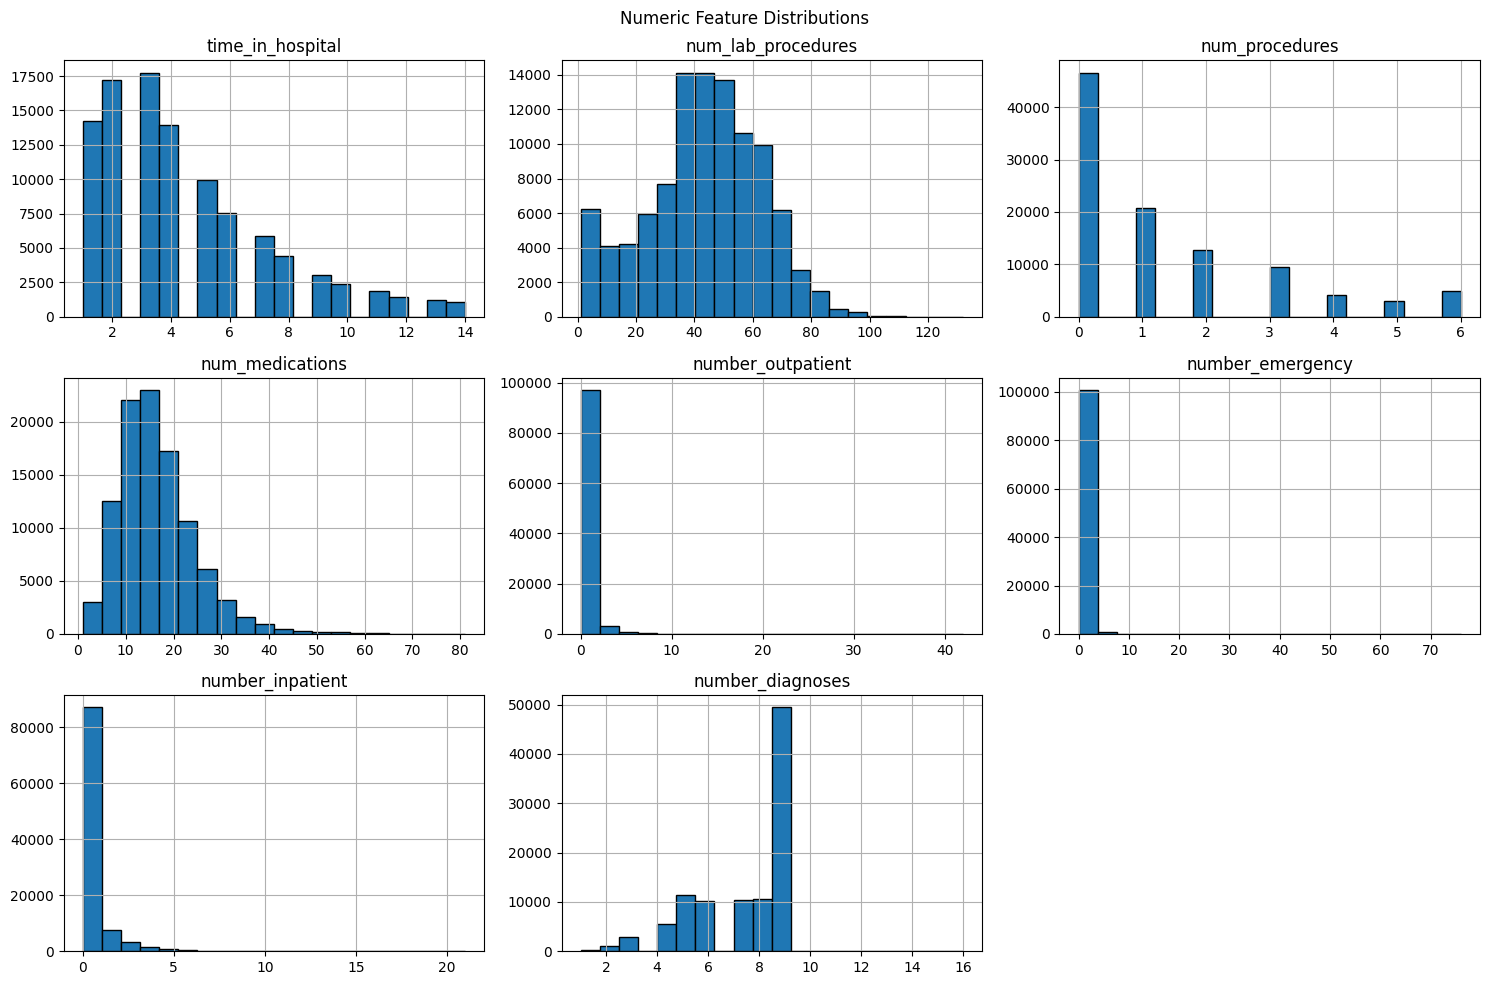

In [88]:
# distribution of numeric features

num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency',
            'number_inpatient', 'number_diagnoses']

diabetic_data_imputed[num_cols].hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.suptitle('Numeric Feature Distributions')
plt.tight_layout()
plt.show()

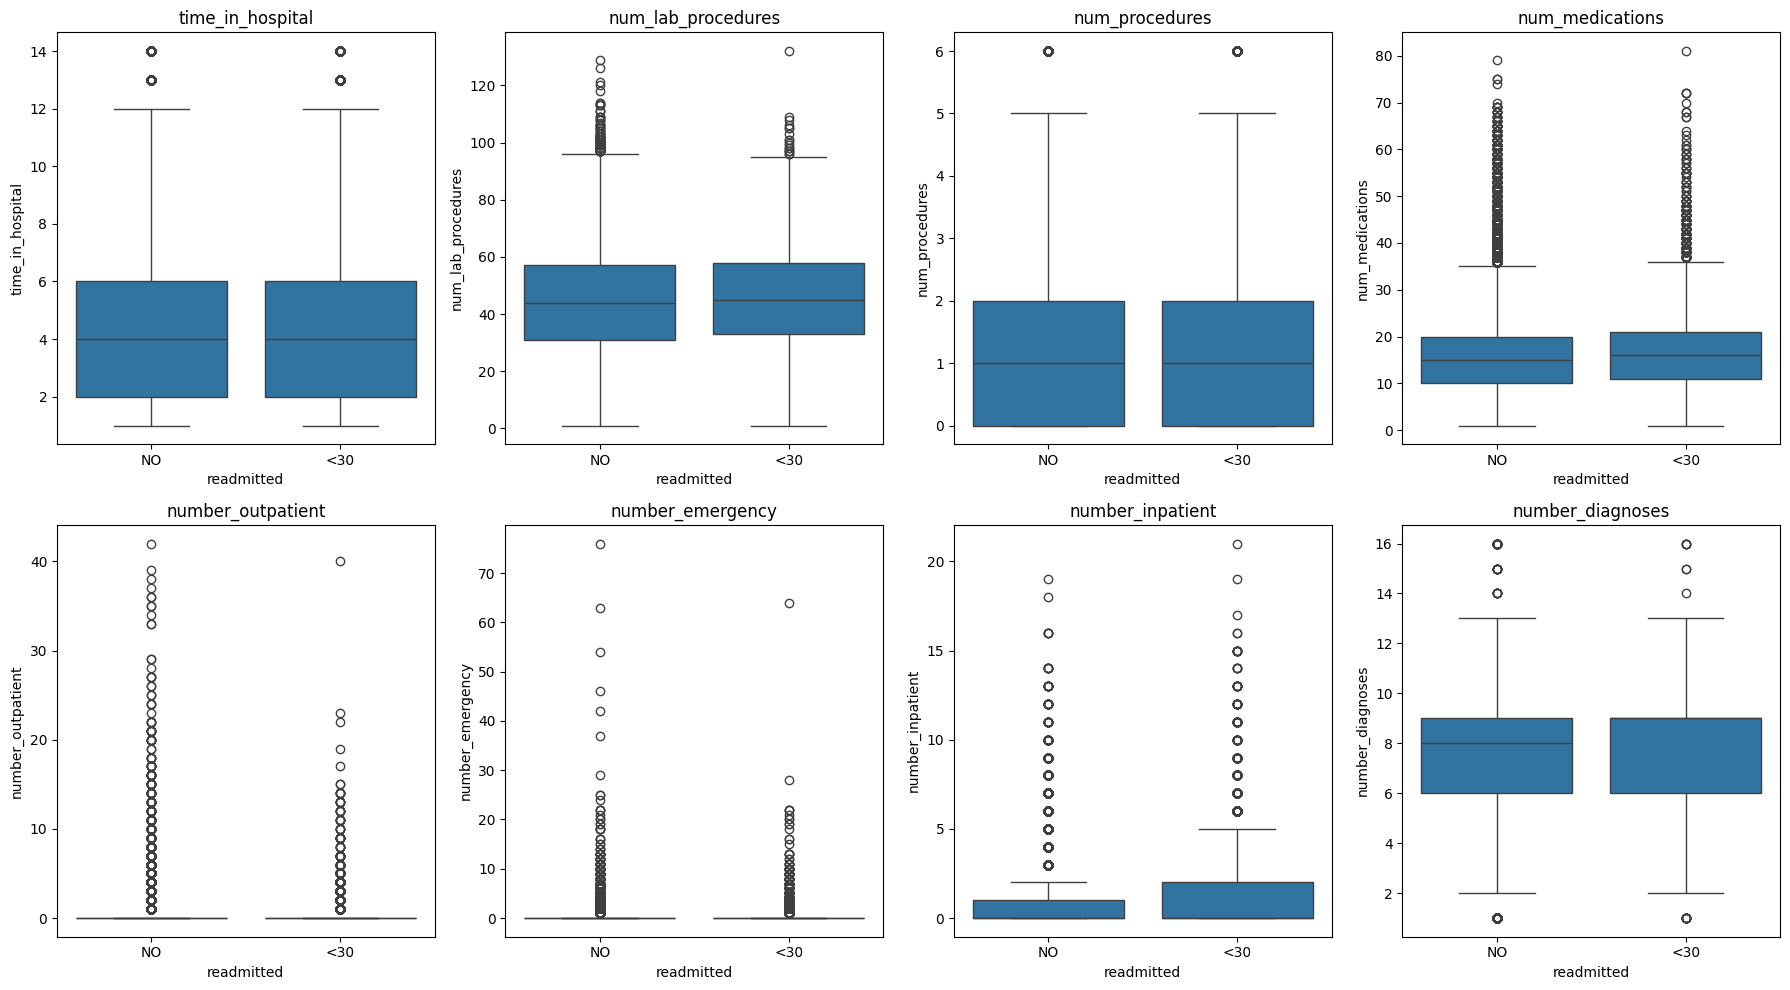

In [89]:
# numeric features by readmission status

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=diabetic_data_imputed, x='readmitted', y=col, 
                order=['NO', '<30'], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# many outliers !! - , num_emergency, num_medications, number_inpatient
# Candidate for log transformation?


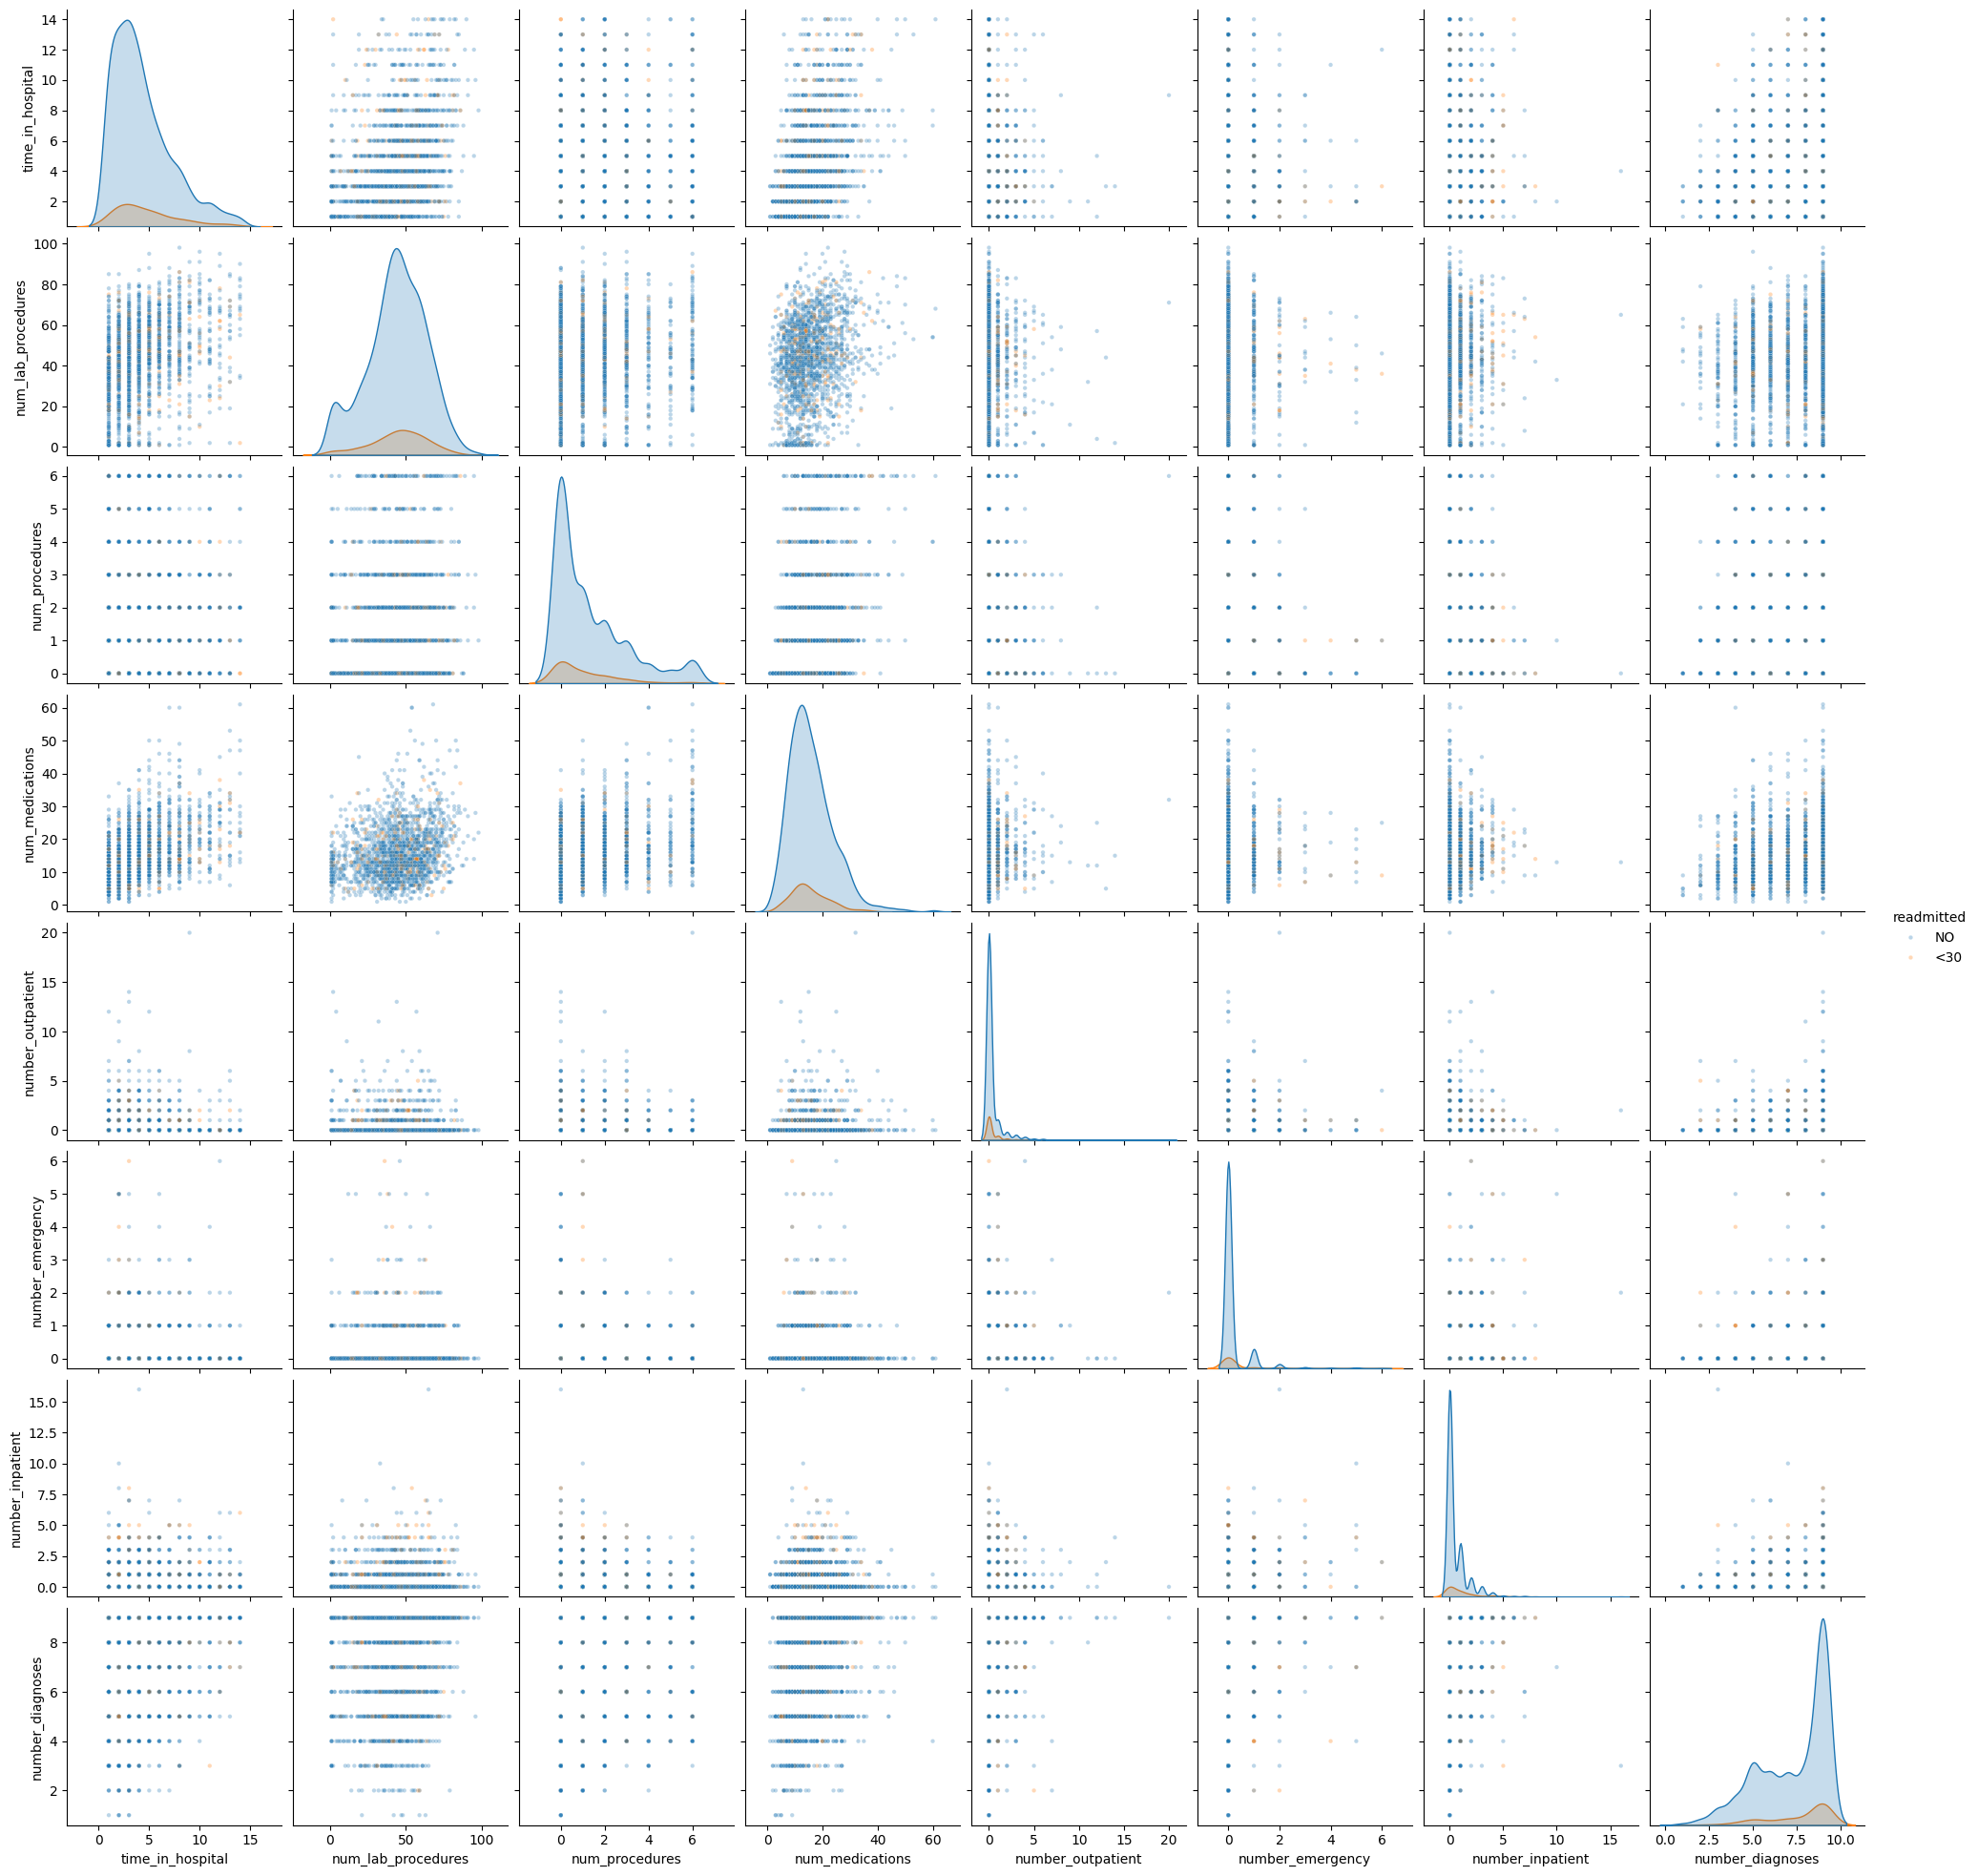

In [92]:
# checking for linear separability???????????
import random
sample = diabetic_data_imputed[num_cols + ['readmitted']].sample(2000, random_state=42)
sns.pairplot(sample, hue='readmitted', hue_order=['NO', '<30'], 
             plot_kws={'alpha': 0.3, 's': 10})
plt.show()

##### Categorical features- with feature engineering

In [93]:
diabetic_data_imputed.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 46 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   patient_nbr               101766 non-null  int64
 1   race                      101766 non-null  str  
 2   gender                    101766 non-null  str  
 3   age                       101766 non-null  str  
 4   admission_type_id         101766 non-null  int64
 5   discharge_disposition_id  101766 non-null  int64
 6   admission_source_id       101766 non-null  int64
 7   time_in_hospital          101766 non-null  int64
 8   num_lab_procedures        101766 non-null  int64
 9   num_procedures            101766 non-null  int64
 10  num_medications           101766 non-null  int64
 11  number_outpatient         101766 non-null  int64
 12  number_emergency          101766 non-null  int64
 13  number_inpatient          101766 non-null  int64
 14  diag_1                    10176

In [94]:
columns_to_drop = ['acetohexamide', 'tolbutamide', 'examide', 'citoglipton',
            'troglitazone', 'tolazamide', 'miglitol', 'acarbose',
            'chlorpropamide', 'nateglinide',
            'glipizide-metformin', 'glyburide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
diabetic_data_imputed.drop(columns=columns_to_drop, inplace=True)

In [ ]:
cat_cols = ['race', 'gender', 'age',
            'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
            'diag_1', 'diag_2', 'diag_3',
            'change', 'diabetesMed']

#### Feature engineering 
- Admission/discharge types
- Diagnostic codes(diag 1, 2 , 3)
- Change in medication
 

In [95]:
admission_type_map = {
    1: 'Emergency', 2: 'Urgent', 3: 'Elective',
    4: 'Newborn', 5: 'Not Available', 6: 'NULL', 7: 'Trauma', 8: 'Not Mapped'
}

discharge_map = {
    1: 'Home', 2: 'Short-term hospital', 3: 'SNF',
    6: 'Home w/ health service', 11: 'Expired',
    18: 'Unknown', 19: 'Expired (hospice)', 20: 'Expired (hospital)',
    25: 'Not Mapped', 26: 'Unknown'
}

admission_source_map = {
    1: 'Physician referral', 4: 'Transfer', 7: 'Emergency room',
    2: 'Clinic referral', 3: 'HMO referral', 17: 'NULL'
}

diabetic_data_imputed['admission_type_id'] = diabetic_data_imputed['admission_type_id'].map(admission_type_map)
diabetic_data_imputed['discharge_disposition_id'] = diabetic_data_imputed['discharge_disposition_id'].map(discharge_map)
diabetic_data_imputed['admission_source_id'] = diabetic_data_imputed['admission_source_id'].map(admission_source_map)

In [96]:
def map_diag(code):
    if pd.isna(code): return 'Unknown'
    code = str(code).strip()
    if code.startswith('250'): return 'Diabetes'
    try:
        n = float(code)
        if 390 <= n <= 459 or n == 785:  return 'Circulatory'
        if 460 <= n <= 519 or n == 786:  return 'Respiratory'
        if 520 <= n <= 579 or n == 787:  return 'Digestive'
        if 800 <= n <= 999:              return 'Injury'
        if 710 <= n <= 739:              return 'Musculoskeletal'
        if 580 <= n <= 629 or n == 788:  return 'Genitourinary'
        if 140 <= n <= 239:              return 'Neoplasms'
        return 'Other'
    except ValueError:
        return 'External'

for col in ['diag_1', 'diag_2', 'diag_3']:
    diabetic_data_imputed[col] = diabetic_data_imputed[col].apply(map_diag)

In [97]:
med_map = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': 2}
active_meds = ['metformin', 'repaglinide', 'glimepiride', 'glipizide',
               'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin']

for col in active_meds:
    diabetic_data_imputed[col] = diabetic_data_imputed[col].map(med_map)

# counts how many of the 8 active meds had their dose adjusted (Up or Down = 2)
diabetic_data_imputed['num_meds_changed'] = (diabetic_data_imputed[active_meds] == 2).sum(axis=1)

In [98]:
cat_cols = ['race', 'gender', 'age',
            'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
            'diag_1', 'diag_2', 'diag_3',
            'change','num_meds_changed', 'diabetesMed']

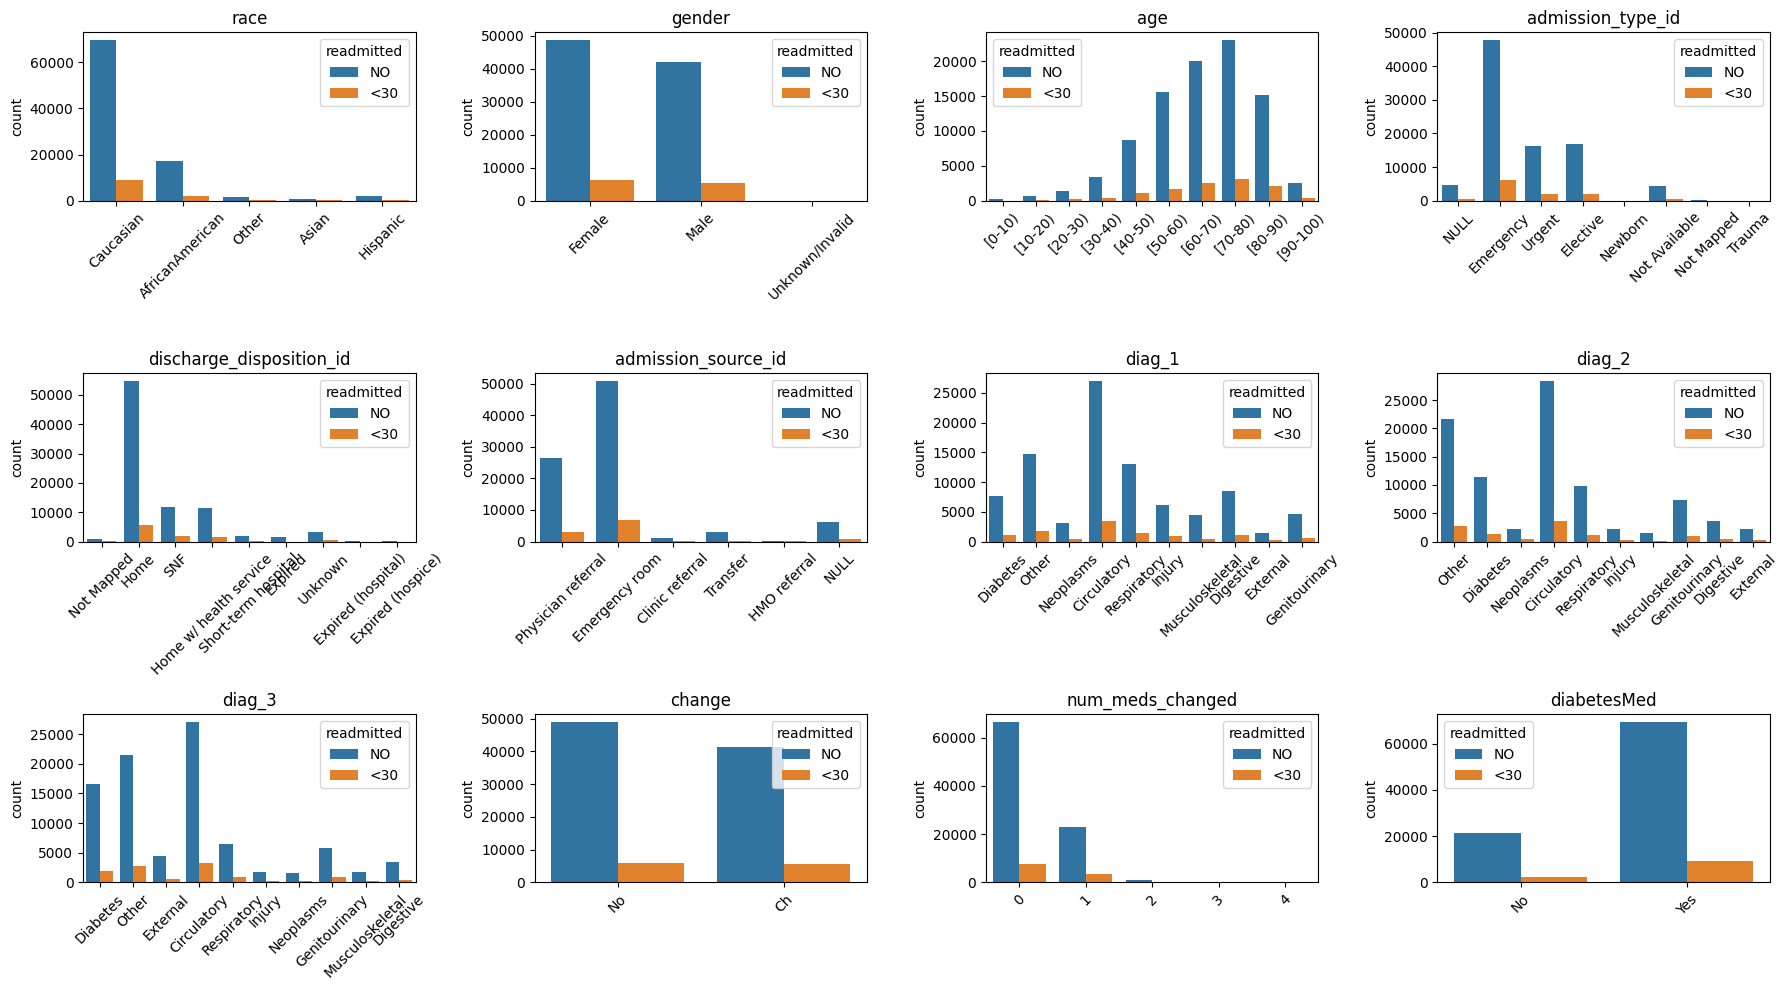

In [99]:
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=diabetic_data_imputed, x=col, hue='readmitted',
                  hue_order=['NO', '<30'], ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()